In [ ]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

reference_dir = '/../../../data/GBM_LEAP_annotations/'
output_dir = '../../../data/Fig3/'
input_dir = '../../../data/Fig1/'
cell_states = ['OPC-NPC-like 1','AC progenitor-like 2','AC progenitor-like 1',
               'AC-gliosis-like 1','Gliosis-like','Hypoxic 1']

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
adata = sc.read_h5ad(os.path.join(reference_dir, 'GBM_LEAP_annotations_v2.22_04_25.webatlas.h5ad'))
adata = adata[:,adata.var['feature_types']=='Gene Expression']

# normalise
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## get HVGs for malignant cells
sc.pp.highly_variable_genes(adata, 
                            min_mean=0.0075, 
                            max_mean=4, 
                            min_disp=0.1,
                            batch_key="donor_id"
)
selected = adata.var['highly_variable']

adata = adata[adata.obs['annotation_granular'].isin(cell_states)]

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [ ]:
# load if finished
deg = pd.read_csv(os.path.join('../../../data/Fig1/Fig1c_degs.csv'), index_col=0)

In [ ]:
# get resources
msigdb = dc.get_resource("MSigDB")

collections = [
    "go_biological_process",
    "go_molecular_function",
    "go_cellular_component",
    "hallmark",
    "kegg_pathways",
    "cell_type_signatures"
]

net = (
    msigdb[msigdb["collection"].isin(collections)]
    [["geneset", "genesymbol"]]
    .drop_duplicates()
)

In [ ]:
geneset_size = net.groupby("geneset").size()
gsea_genesets = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)]

In [ ]:
t_stats_all = {}
for state in set(cell_states):
    # extract scores
    t_stats = (
        # Get dataframe of DE results for condition vs. rest
        deg[deg['group']==state]\
        # Subset to highly variable genes
        .set_index("names")
        .loc[selected]
        # Sort by absolute score
        .sort_values("scores", key=np.abs, ascending=False)
        # Format for decoupler
        [["scores"]]
        .rename_axis([state], axis=1)
    )
    t_stats_all[state] = t_stats

In [ ]:
gsea_results_all = {}
for state in set(cell_states):
    print(state)
    scores, norm, pvals = dc.run_gsea(
        t_stats_all[state].T,
        net[net["geneset"].isin(gsea_genesets)],
        source="geneset",
        target="genesymbol",
        batch_size = None
    )
    gsea_results = (
        pd.concat({"score": scores.T, "norm": norm.T, "pval": pvals.T}, axis=1)
        .droplevel(level=1, axis=1)
        .sort_values("pval")
    )
    gsea_results.to_csv(os.path.join('../data/perinecrotic_validation',
                                     'GSEA', '{}_gsea_results.txt'.format(state)), sep = '\t')
    gsea_results_all[state] = gsea_results

Gliosis-like
AC progenitor-like 2
AC progenitor-like 1
AC-gliosis-like 1
Hypoxic 1
OPC-NPC-like 1


In [ ]:
gsea_results_all = {}
for state in cell_states:
    gsea_results = pd.read_csv(os.path.join('../data/perinecrotic_validation',
                                     'GSEA', '{}_gsea_results.txt'.format(state)), sep = '\t', index_col=0)
    
    gsea_results_all[state] = gsea_results

In [ ]:
ct = 'AC-gliosis-like 1'
(gsea_results_all[ct][gsea_results_all[ct].index.str.contains('cadh', case=False)]).head(20)

,score,norm,pval
source,,,
GOMF_CADHERIN_BINDING_INVOLVED_IN_CELL_CELL_ADHESION,0.783688,1.439302,0.053170
GOBP_POSITIVE_REGULATION_OF_CELL_CELL_ADHESION_MEDIATED_BY_CADHERIN,0.747987,1.182314,0.350220
GOBP_REGULATION_OF_CELL_CELL_ADHESION_MEDIATED_BY_CADHERIN,0.491012,0.897256,0.626582
GOBP_CELL_CELL_ADHESION_MEDIATED_BY_CADHERIN,-0.356201,-0.814556,0.759575
GOBP_NEGATIVE_REGULATION_OF_CELL_CELL_ADHESION_MEDIATED_BY_CADHERIN,0.414044,0.700320,0.829004


In [ ]:
ct = 'AC progenitor-like 1'
gsea_results_all[ct][(gsea_results_all[ct]['norm']>1) &
    (gsea_results_all[ct]['pval']<0.01)].sort_values(['pval']).head(50)

,score,norm,pval
source,,,
AIZARANI_LIVER_C10_MVECS_1,0.642448,1.627087,0.0
GOBP_POSITIVE_REGULATION_OF_PHOSPHATIDYLINOSITOL_3_KINASE_PROTEIN_KINASE_B_SIGNAL_TRANSDUCTION,0.667566,1.620383,0.0
HALLMARK_ALLOGRAFT_REJECTION,0.627114,1.547484,0.0
HALLMARK_COAGULATION,0.767090,1.788425,0.0
TRAVAGLINI_LUNG_MACROPHAGE_CELL,0.642918,1.590294,0.0
MENON_FETAL_KIDNEY_9_ENDOTHELIAL_CELLS,0.709673,1.612062,0.0
MENON_FETAL_KIDNEY_5_PROXIMAL_TUBULE_CELLS,0.711901,1.630334,0.0
TRAVAGLINI_LUNG_MYOFIBROBLAST_CELL,0.782172,1.713428,0.0
GOBP_OSTEOBLAST_DIFFERENTIATION,0.678664,1.664425,0.0


In [ ]:
selected_pathways = [
    'ZHONG_PFC_MAJOR_TYPES_ASTROCYTES',
    'GOBP_RESPONSE_TO_TYPE_II_INTERFERON', #?
    'GOBP_POSITIVE_REGULATION_OF_IMMUNE_EFFECTOR_PROCESS',
    'GOBP_INTEGRIN_MEDIATED_SIGNALING_PATHWAY',
    'GOMF_CADHERIN_BINDING_INVOLVED_IN_CELL_CELL_ADHESION',
    'GOBP_REGULATION_OF_WOUND_HEALING',
    'GOBP_INDUCTION_OF_POSITIVE_CHEMOTAXIS',
    'GOBP_POSITIVE_REGULATION_OF_VASCULATURE_DEVELOPMENT',
    'HALLMARK_HYPOXIA',
    'HALLMARK_IL6_JAK_STAT3_SIGNALING',
    'GOBP_TUMOR_NECROSIS_FACTOR_SUPERFAMILY_CYTOKINE_PRODUCTION',
    'GOBP_INTEGRATED_STRESS_RESPONSE_SIGNALING',
    'GOBP_PROTEIN_FOLDING'
]

In [ ]:
filtered_pathway_df = []
for ct in gsea_results_all:
    res = gsea_results_all[ct][gsea_results_all[ct].index.isin(selected_pathways)].copy()
    res['state'] = ct
    filtered_pathway_df.append(res)
filtered_pathway_df = pd.concat(filtered_pathway_df).reset_index()

p_floor = 1 / (2000 + 1)

filtered_pathway_df["pval_plot"] = (
    filtered_pathway_df["pval"]
    .clip(lower=p_floor)
)
filtered_pathway_df["ng_log_p"] = -np.log(
    filtered_pathway_df["pval_plot"]
)

In [ ]:
filtered_pathway_df["state"] = pd.Categorical(
    filtered_pathway_df["state"],
    categories=cell_states,
    ordered=True
)

filtered_pathway_df["source"] = pd.Categorical(
    filtered_pathway_df["source"],
    categories=selected_pathways,
    ordered=True
)

#filtered_pathway_df = filtered_pathway_df[filtered_pathway_df['pval']<=0.05]

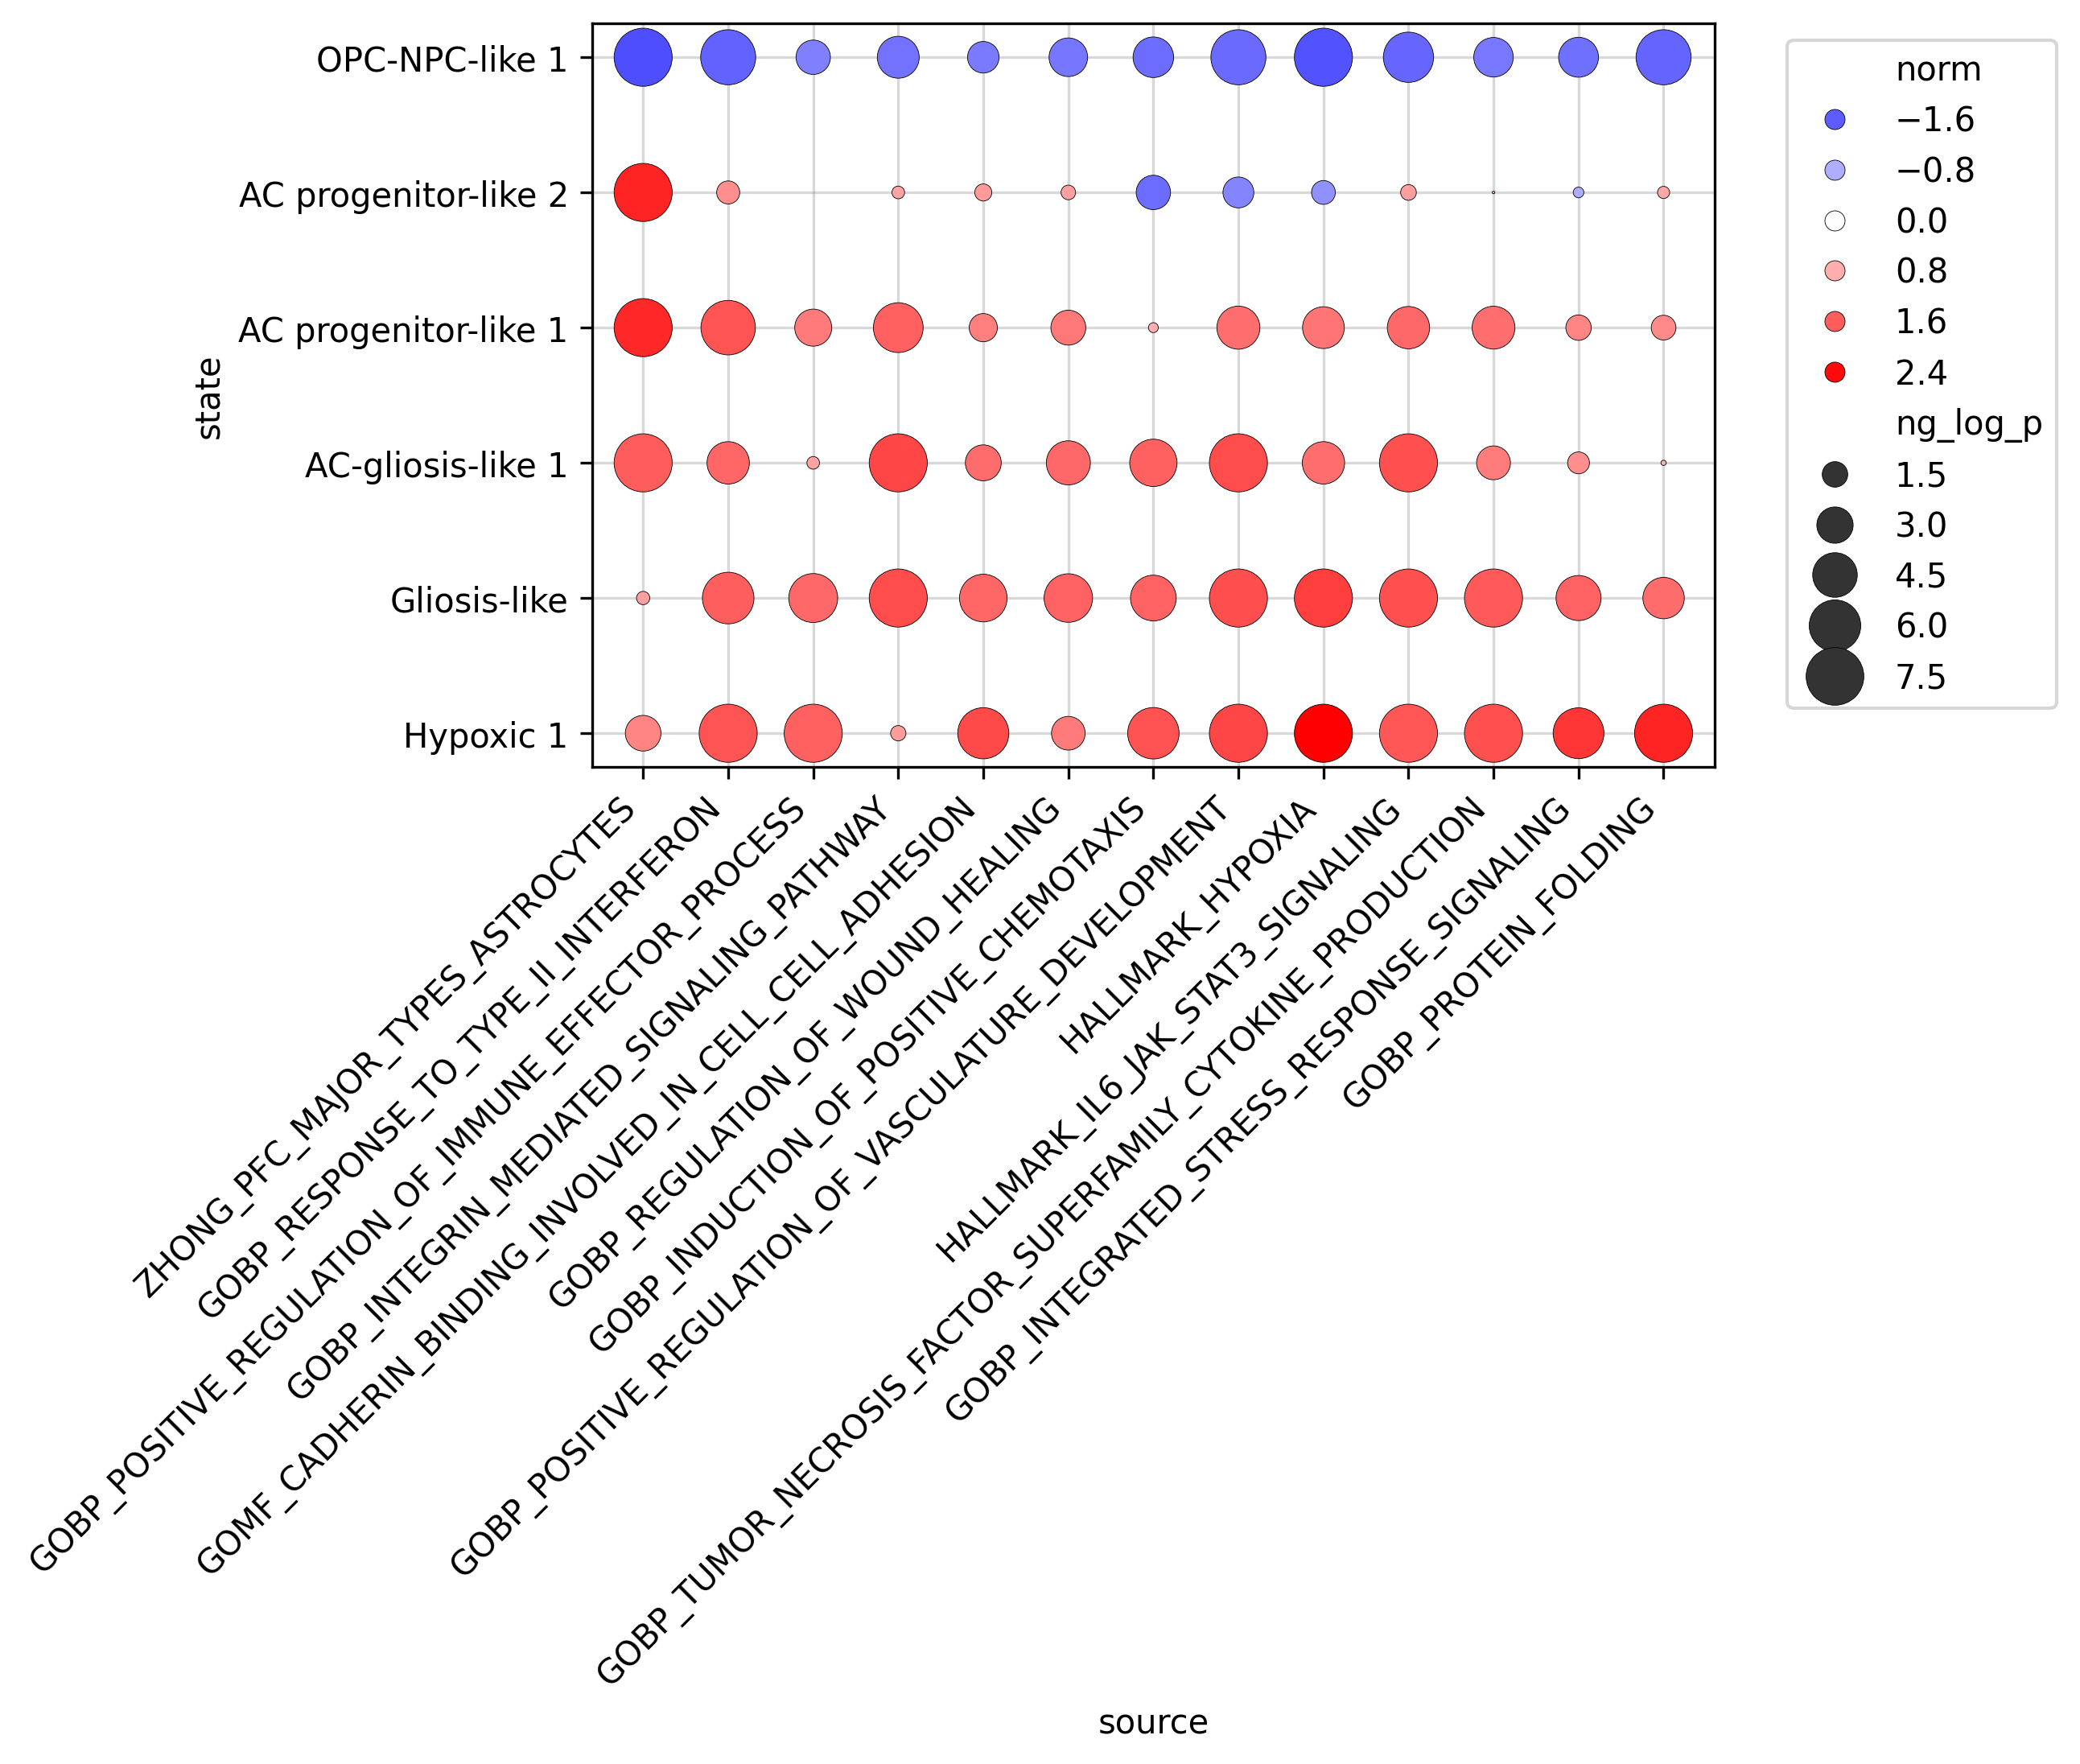

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.scatterplot(data = filtered_pathway_df, y = 'state', x = 'source',
                hue = 'norm', size = 'ng_log_p', 
                linewidth = 0.2, edgecolor = 'black',
                palette = 'bwr', #'RdBu_r', 
                sizes=(0, 300), hue_norm = (-2.5, 2.5))
plt.xticks(rotation=45, ha="right")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
ax.grid(True, color="grey", alpha=0.3, zorder=-1)
ax.set_axisbelow(True)
plt.savefig('../data/plots/perinecrotic_validation/Fig3a_GSEA.pdf')
filtered_pathway_df.to_csv(f'{output_dir}/Fig3a2.csv')